In [26]:
import os
import pandas as pd
import polars as pl 
from dotenv import load_dotenv
from pymongo import MongoClient 
import missingno as msno
import glob

1. Chargement et instance du dataset

In [27]:
load_dotenv()
uri = os.getenv("MONGO_URI")
client = MongoClient(uri)
client.admin. command('ping')

ServerSelectionTimeoutError: container-mongo1:27017: [Errno -3] Temporary failure in name resolution (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms),container-mongo2:27018: [Errno -3] Temporary failure in name resolution (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms),container-mongo3:27019: [Errno -3] Temporary failure in name resolution (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms), Timeout: 30s, Topology Description: <TopologyDescription id: 6a4588408e65bb215fbcbb0f, topology_type: ReplicaSetNoPrimary, servers: [<ServerDescription ('container-mongo1', 27017) server_type: Unknown, rtt: None, error=AutoReconnect('container-mongo1:27017: [Errno -3] Temporary failure in name resolution (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms)')>, <ServerDescription ('container-mongo2', 27018) server_type: Unknown, rtt: None, error=AutoReconnect('container-mongo2:27018: [Er

In [ ]:
files = glob.glob("../data/listings*.csv")

frames = []
for path in files:
    city = path.split("listings")[1].split(".")[0]
    df = pl.read_csv(path)
    df = df.with_columns(pl.lit(city).alias("city"))
    frames.append(df)
dfv0 = pl.concat(frames)

2. Mapping

In [ ]:
TYPE_MAPPING = {
    "Int64": [
        "id",
        "scrape_id",
        "host_id",
        "accommodates",
        "minimum_nights",
        "maximum_nights",
        "minimum_minimum_nights",
        "maximum_minimum_nights",
        "minimum_maximum_nights",
        "maximum_maximum_nights",
        "availability_30",
        "availability_60",
        "availability_90",
        "availability_365",
        "number_of_reviews",
        "number_of_reviews_ltm",
        "number_of_reviews_l30d",
        "calculated_host_listings_count",
        "calculated_host_listings_count_entire_homes",
        "calculated_host_listings_count_private_rooms",
        "calculated_host_listings_count_shared_rooms",
        "bedrooms",
        "beds",
        "host_listings_count",
        "host_total_listings_count",
    ],
    "Float64Specific": [
        "price",
        "host_response_rate",
        "host_acceptance_rate", 
    ],
    "Float64": [
        "latitude",
        "longitude",
        "minimum_nights_avg_ntm",
        "maximum_nights_avg_ntm",
        "bathrooms",
        "reviews_per_month",
        "review_scores_rating",
        "review_scores_accuracy",
        "review_scores_cleanliness",
        "review_scores_checkin",
        "review_scores_communication",
        "review_scores_location",
        "review_scores_value",
    ],
    "Boolean": [
        "host_is_superhost",
        "host_has_profile_pic",
        "host_identity_verified",
        "has_availability",
        "instant_bookable",
    ],
    "Date": [
        "last_scraped",
        "host_since",
        "calendar_last_scraped",
        "first_review",
        "last_review",
    ],
    "String": [
        "listing_url",
        "source",
        "name",
        "description",
        "neighborhood_overview",
        "picture_url",
        "host_url",
        "host_name",
        "host_location",
        "host_about",
        "host_response_time",
        "host_thumbnail_url",
        "host_picture_url",
        "host_neighbourhood", 
        "neighbourhood",
        "neighbourhood_cleansed",
        "property_type",
        "room_type",
        "bathrooms_text",
        "license",
    ],
    "List": [
        "amenities",
        "host_verifications",
    ]
}

FIELD_MAPPING = {
    "availability": [
        "availability_30",
        "availability_60",
        "availability_90",
        "availability_365",
        "has_availability",
        "instant_bookable",
    ],
    "host": [
        "calculated_host_listings_count",
        "calculated_host_listings_count_entire_homes",
        "calculated_host_listings_count_private_rooms",
        "calculated_host_listings_count_shared_rooms",
        "host_about",
        "host_acceptance_rate",
        "host_has_profile_pic",
        "host_id",
        "host_identity_verified",
        "host_is_superhost",
        "host_listings_count",
        "host_location",
        "host_name",
        "host_neighbourhood",
        "host_picture_url",
        "host_response_rate",
        "host_response_time",
        "host_since",
        "host_thumbnail_url",
        "host_total_listings_count",
        "host_url",
        "host_verifications",
    ],
    "location": [
        "latitude",
        "longitude",
        "neighbourhood",
        "neighbourhood_cleansed",
        "neighborhood_overview",
    ],
    "night": [
        "maximum_maximum_nights",
        "maximum_minimum_nights",
        "maximum_nights",
        "maximum_nights_avg_ntm",
        "minimum_maximum_nights",
        "minimum_minimum_nights",
        "minimum_nights",
        "minimum_nights_avg_ntm",
    ],
    "property": [
        "accommodates",
        "amenities",
        "bathrooms",
        "bathrooms_text",
        "bedrooms",
        "beds",
        "property_type",
        "room_type",
    ],
    "review": [
        "first_review",
        "last_review",
        "number_of_reviews",
        "number_of_reviews_l30d",
        "number_of_reviews_ltm",
        "review_scores_accuracy",
        "review_scores_checkin",
        "review_scores_cleanliness",
        "review_scores_communication",
        "review_scores_location",
        "review_scores_rating",
        "review_scores_value",
        "reviews_per_month",
    ],
    "scraping": [
        "calendar_last_scraped",
        "last_scraped",
        "scrape_id",
        "source",
    ],
    "root": [
        "id",
        "city",
        "description",
        "license",
        "listing_url",
        "name",
        "picture_url",
        "price",
    ],
}

3. Nettoyage NAN, duplcates, col

<Axes: >

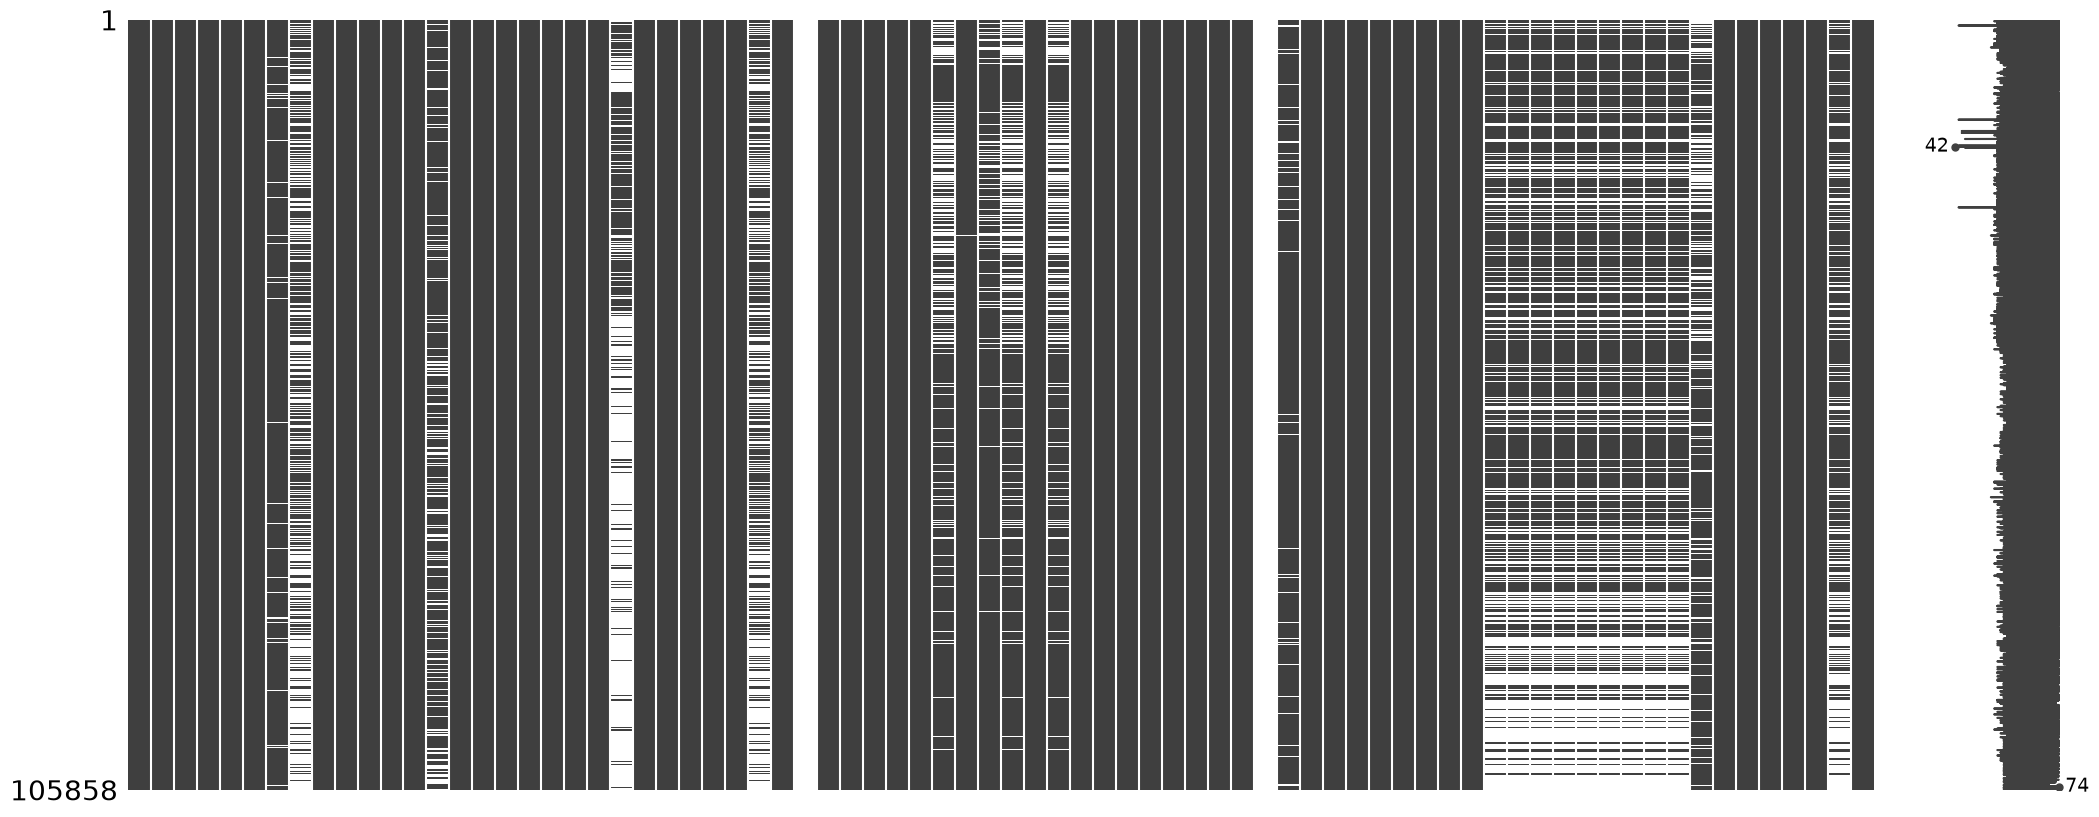

In [ ]:
# Base actuelle
msno.matrix(dfv0.to_pandas())

<Axes: >

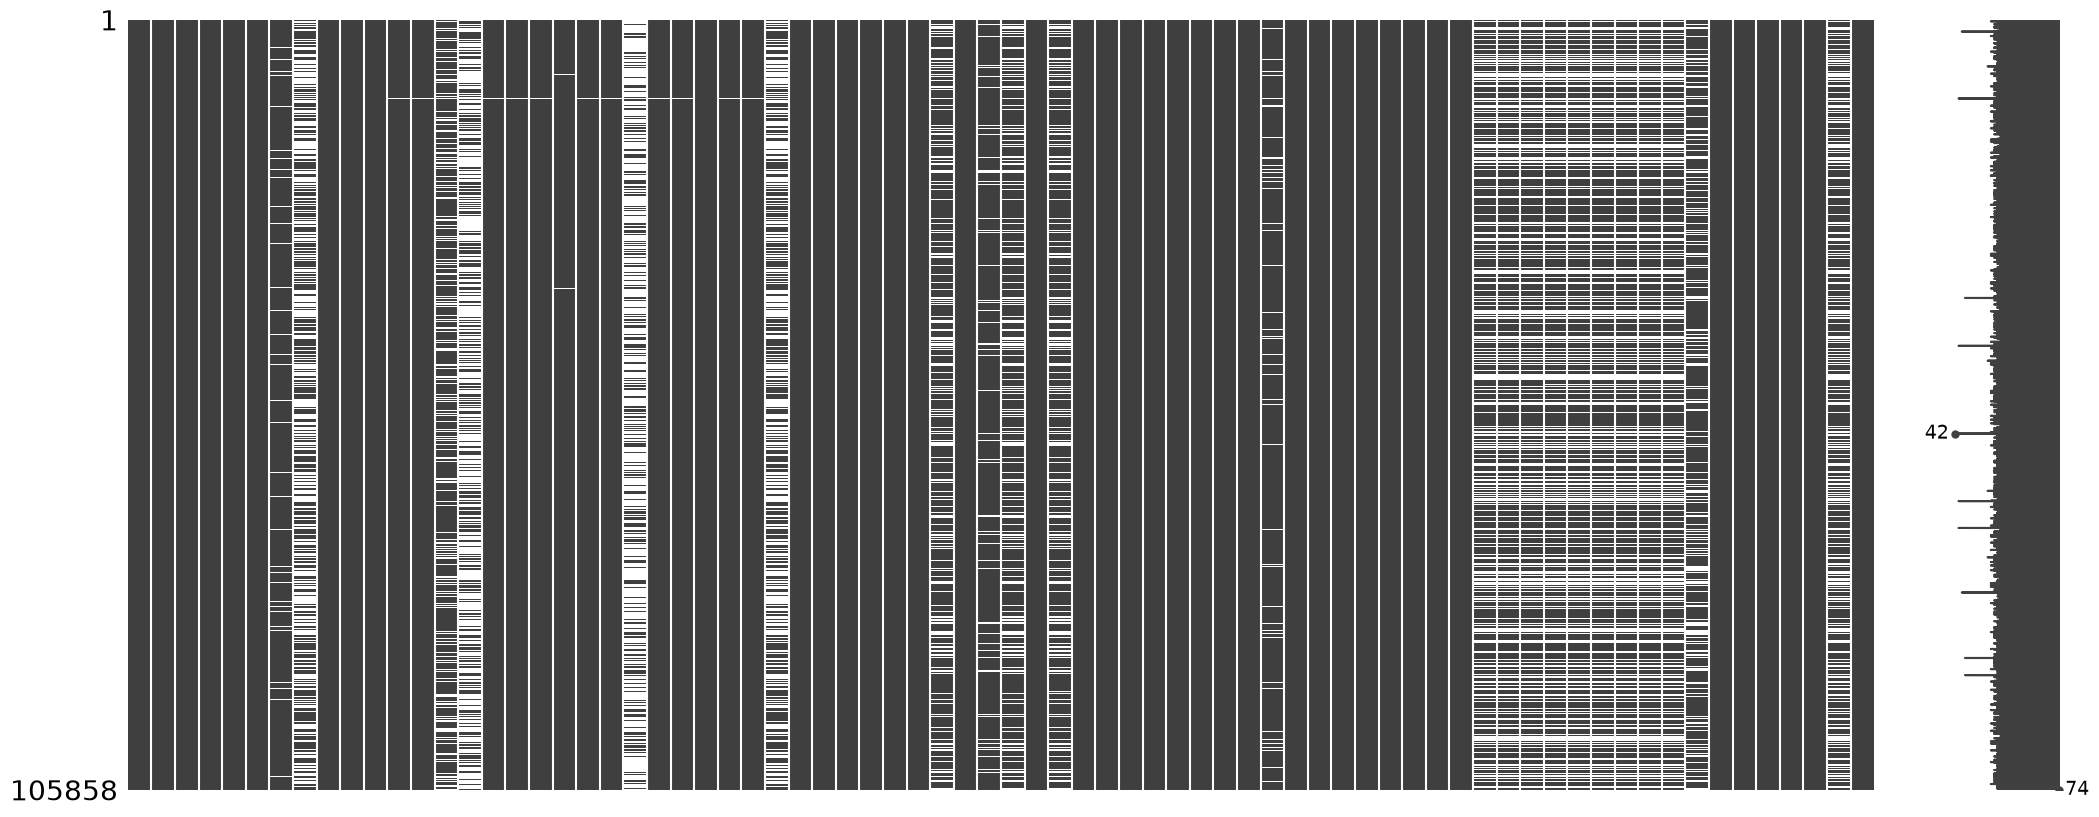

In [ ]:
def clean(dfv0:pl.DataFrame):
    dfv0 = dfv0.with_columns(
    pl.col(pl.String).str.strip_chars().replace("", None)
    )
    dfv0 = dfv0.unique(subset=["id"])
    empty_col = [c for c in dfv0.columns if dfv0[c].null_count() / dfv0.height > 0.99]
    dfv0 = dfv0.drop(empty_col)
    return dfv0

dfv1 = clean(dfv0)

# Base nettoyée
msno.matrix(dfv1.to_pandas())

4. Casting

In [ ]:
def cast(dfv1:pl.DataFrame):
    dfv1 = dfv1.with_columns(
        *[pl.col(c).str.replace_all(r"[$,%]", "").cast(pl.Float64, strict=False) for c in TYPE_MAPPING["Float64Specific"]],
        *[pl.col(c).cast(pl.Int64, strict=False) for c in TYPE_MAPPING["Int64"]],
        *[pl.col(c).cast(pl.Float64, strict=False) for c in TYPE_MAPPING["Float64"]],
        *[pl.col(c).str.to_datetime() for c in TYPE_MAPPING["Date"]], 
        *[(pl.col(c) == "t").alias(c) for c in TYPE_MAPPING["Boolean"]],
        pl.col("host_verifications").str.replace_all("'", '"').str.replace_all("None", "null").str.json_decode(dtype=pl.List(pl.String)),
        pl.col("amenities").str.json_decode(dtype=pl.List(pl.String)),
    )
    return dfv1

dfv2 = cast(dfv1)

dfv2.head(1)

id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
i64,str,i64,datetime[μs],str,str,str,str,str,i64,str,str,datetime[μs],str,str,str,f64,f64,bool,str,str,str,i64,i64,list[str],bool,bool,str,str,f64,f64,str,str,i64,f64,str,i64,i64,list[str],f64,i64,i64,i64,i64,i64,i64,f64,f64,bool,i64,i64,i64,i64,datetime[μs],i64,i64,i64,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,str,bool,i64,i64,i64,i64,f64,str
1044725834150766897,"""https://www.airbnb.com/rooms/1…",20240610195007,2024-06-11 00:00:00,"""city scrape""","""GuestReady - Lovely stay in Qu…","""This one-bedroom apartment in …","""This property offers a great l…","""https://a0.muscache.com/pictur…",550629507,"""https://www.airbnb.com/users/s…","""Raphael""",2023-12-12 00:00:00,null,"""At GuestReady, we're on a miss…","""within an hour""",100.0,100.0,false,"""https://a0.muscache.com/im/pic…","""https://a0.muscache.com/im/pic…",null,1,1,"[""email"", ""phone""]",true,true,"""Neighborhood highlights""","""Gobelins""",48.82292,2.35207,"""Entire rental unit""","""Entire home/apt""",2,1.0,"""1 bath""",1,1,"[""Smoke alarm"", ""Dishwasher"", … ""Iron""]",130.0,1,1125,1,4,2,1125,2.8,369.5,true,15,45,75,256,2024-06-11 00:00:00,2,2,0,2024-01-02 00:00:00,2024-03-31 00:00:00,5.0,4.5,4.5,3.5,4.5,4.0,4.5,"""7511310422080""",true,1,1,0,0,0.37,"""Paris"""


5.Reshape

In [ ]:
def reshape(dfv2:pl.DataFrame):
    MAPPING = {name:[c for c in cols if c in dfv2.columns] for name, cols in FIELD_MAPPING.items()}
    dfv2 = dfv2.with_columns(*[pl.struct(cols).alias(name) for name, cols in MAPPING.items() if name != "root"])
    dfv2 = dfv2.drop(*[c for name, cols in MAPPING.items() if name != "root" for c in cols])
    return dfv2

dfv3 = reshape(dfv2)

dfv3.columns

['id',
 'listing_url',
 'name',
 'description',
 'picture_url',
 'price',
 'license',
 'city',
 'availability',
 'host',
 'location',
 'night',
 'property',
 'review',
 'scraping']

In [ ]:
# check
print(f"Origine: {[c for c in dfv0.columns if c.startswith("neigh")]}")
print(f"Après clean: {[c for c in dfv1.columns if c.startswith("neigh")]}")
print(f"Après casting: {[c for c in dfv2.columns if c.startswith("neigh")]}")
print(f"Après reshape: {[c for c in dfv3.columns if c.startswith("neigh")]}")

Origine: ['neighborhood_overview', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed']
Après clean: ['neighborhood_overview', 'neighbourhood', 'neighbourhood_cleansed']
Après casting: ['neighborhood_overview', 'neighbourhood', 'neighbourhood_cleansed']
Après reshape: []


In [ ]:
# test
dfv3.select("location").head(3)

location
struct[5]
"{48.82292,2.35207,""Neighborhood highlights"",""Gobelins"",""This property offers a great location for exploring the city. With attractions such as the Louvre Museum, Jardin du Luxembourg, and Musée d'Orsay nearby, guests can easily access some of the most renowned cultural sites in Paris. Additionally, the area is home to a variety of restaurants and bars, including Café Oz, The Australian Bar Denfert and Phở Bánh Cuốn 14, ensuring that guests can indulge in a diverse range of culinary experiences. Whether you are interested in art and history or want to immerse yourself in the vibrant atmosphere of Paris, This address provides a convenient and exciting base for your city exploration.""}"
"{45.740467,4.862879,""Neighborhood highlights"",""8e Arrondissement"",""within a 3-minute walk :Tram, Blandan Park, Self-service bikes, Inter-market, Bowling, Gym, Pizzeria, Pharmacy""}"
"{48.87257,2.2911,null,""Passy"",null}"


6.Chargement

In [ ]:
def load(dfv3, client):
    db = client["airbnb"]
    collection = db["listings"]
    collection.drop()
    docs = dfv3.to_dicts()
    collection.insert_many(docs)
    return collection.count_documents({})

load(dfv3, client)

105858

In [ ]:
dfv3.head

<bound method DataFrame.head of shape: (105_858, 15)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ id        ┆ listing_u ┆ name      ┆ descripti ┆ … ┆ night     ┆ property  ┆ review    ┆ scraping │
│ ---       ┆ rl        ┆ ---       ┆ on        ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ i64       ┆ ---       ┆ str       ┆ ---       ┆   ┆ struct[8] ┆ struct[8] ┆ struct[13 ┆ struct[4 │
│           ┆ str       ┆           ┆ str       ┆   ┆           ┆           ┆ ]         ┆ ]        │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 104472583 ┆ https://w ┆ GuestRead ┆ This one- ┆ … ┆ {1125,4,1 ┆ {2,["Smok ┆ {2024-01- ┆ {2024-06 │
│ 415076689 ┆ ww.airbnb ┆ y -       ┆ bedroom   ┆   ┆ 125,369.5 ┆ e alarm", ┆ 02 00:00: ┆ -11 00:0 │
│ 7         ┆ .com/room ┆ Lovely    ┆ apartment ┆   ┆ ,2,1,1,2. ┆ "Dishwash ┆ 00,2024-0 ┆ 0:00,202 │
│           ┆ s/1…      ┆ stay in   ┆ 